In [1]:
# =========================================================
# Day 6. 앙상블 / AutoML / 발표 실습
# scikit-learn wine 데이터셋 기준
#
# 구성
# 1) 데이터 로드
# 2) 기준 모델(Baseline)
# 3) Bagging
# 4) Boosting
# 5) Voting
# 6) Stacking
# 7) "간단 AutoML" (여러 모델 자동 비교)
# 8) 중요 변수 해석
# 9) 발표용 결과 표 정리
# =========================================================

In [2]:
# ---------------------------------------------------------
# 1. 라이브러리 불러오기
# ---------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [3]:
# ---------------------------------------------------------
# 2. 기본 설정
# ---------------------------------------------------------
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)

In [4]:
# ---------------------------------------------------------
# 3. 데이터 불러오기
# ---------------------------------------------------------
wine = load_wine(as_frame=True)
df = wine.frame.copy()

print("=== 데이터 상위 5행 ===")
display(df.head())

=== 데이터 상위 5행 ===


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
print("=== 데이터 크기 ===")
print(df.shape)

=== 데이터 크기 ===
(178, 14)


In [6]:
print("=== 컬럼 목록 ===")
print(df.columns.tolist())

=== 컬럼 목록 ===
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']


In [7]:
print("=== target 분포 ===")
display(df["target"].value_counts().sort_index())

=== target 분포 ===


target
0    59
1    71
2    48
Name: count, dtype: int64

In [8]:
# ---------------------------------------------------------
# 4. 입력(X) / 정답(y) 분리
# ---------------------------------------------------------
X = df.drop(columns="target")
y = df["target"]

print("=== X, y 크기 ===")
print("X shape:", X.shape)
print("y shape:", y.shape)

=== X, y 크기 ===
X shape: (178, 13)
y shape: (178,)


In [9]:
# ---------------------------------------------------------
# 5. train / test 분리
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=== train / test 크기 ===")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

=== train / test 크기 ===
X_train: (142, 13)
X_test : (36, 13)


In [10]:
# ---------------------------------------------------------
# 6. 공통 평가 함수
# ---------------------------------------------------------
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    print(f"\n=== {model_name} 결과 ===")
    print("Accuracy:", round(acc, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("\n[Classification Report]")
    print(classification_report(y_test, y_pred))

    return {
        "model_name": model_name,
        "model": model,
        "y_pred": y_pred,
        "accuracy": acc,
        "macro_f1": macro_f1
    }


=== Baseline - Logistic Regression 결과 ===
Accuracy: 0.9444
Macro F1: 0.9407

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.88      1.00      0.93        14
           2       1.00      0.80      0.89        10

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



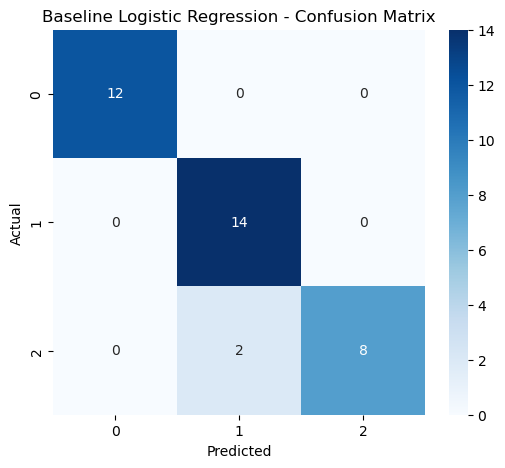

In [11]:
# ---------------------------------------------------------
# 7. 기준 모델(Baseline)
# ---------------------------------------------------------
baseline_lr = LogisticRegression(max_iter=2000, random_state=42)
result_lr = evaluate_model(
    baseline_lr, X_train, y_train, X_test, y_test,
    model_name="Baseline - Logistic Regression"
)

cm_lr = confusion_matrix(y_test, result_lr["y_pred"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


=== Bagging - DecisionTree base 결과 ===
Accuracy: 1.0
Macro F1: 1.0

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



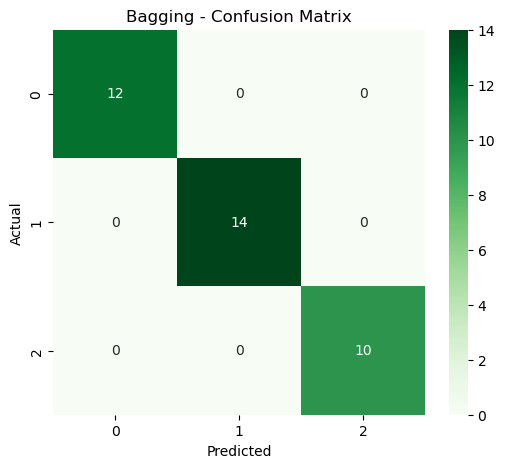

In [12]:
# ---------------------------------------------------------
# 8. Bagging
#    - 하나의 약한 모델을 여러 번 학습해서 합치는 방식
# ---------------------------------------------------------
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

result_bagging = evaluate_model(
    bagging_model, X_train, y_train, X_test, y_test,
    model_name="Bagging - DecisionTree base"
)

cm_bag = confusion_matrix(y_test, result_bagging["y_pred"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bag, annot=True, fmt="d", cmap="Greens")
plt.title("Bagging - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


=== Boosting - AdaBoost 결과 ===
Accuracy: 0.9167
Macro F1: 0.9198

[Classification Report]
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       0.92      0.86      0.89        14
           2       1.00      0.90      0.95        10

    accuracy                           0.92        36
   macro avg       0.93      0.92      0.92        36
weighted avg       0.92      0.92      0.92        36



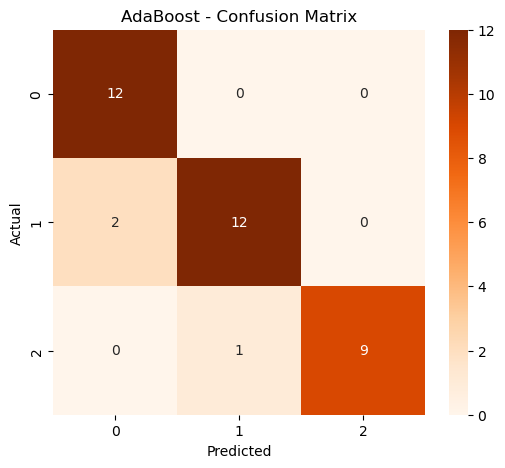

In [13]:
# ---------------------------------------------------------
# 9. Boosting 1 - AdaBoost
# ---------------------------------------------------------
adaboost_model = AdaBoostClassifier(
    n_estimators=200,
    random_state=42
)

result_adaboost = evaluate_model(
    adaboost_model, X_train, y_train, X_test, y_test,
    model_name="Boosting - AdaBoost"
)

cm_ada = confusion_matrix(y_test, result_adaboost["y_pred"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ada, annot=True, fmt="d", cmap="Oranges")
plt.title("AdaBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


=== Boosting - GradientBoosting 결과 ===
Accuracy: 0.9444
Macro F1: 0.9453

[Classification Report]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       0.93      0.93      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



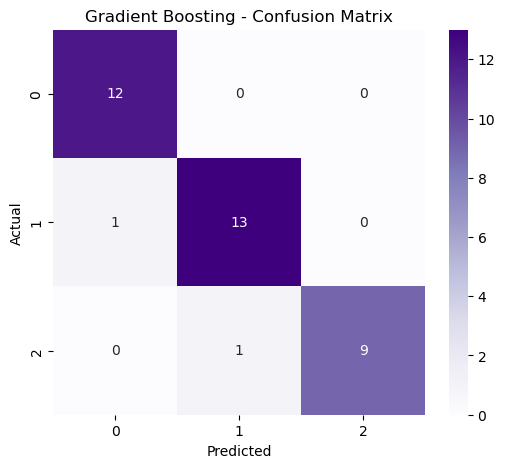

In [14]:
# ---------------------------------------------------------
# 10. Boosting 2 - Gradient Boosting
# ---------------------------------------------------------
gb_model = GradientBoostingClassifier(random_state=42)

result_gb = evaluate_model(
    gb_model, X_train, y_train, X_test, y_test,
    model_name="Boosting - GradientBoosting"
)

cm_gb = confusion_matrix(y_test, result_gb["y_pred"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Purples")
plt.title("Gradient Boosting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
# ---------------------------------------------------------
# 11. Random Forest / Extra Trees
#    - 실무에서 자주 쓰는 강한 트리 앙상블
# ---------------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

result_rf = evaluate_model(
    rf_model, X_train, y_train, X_test, y_test,
    model_name="Ensemble - Random Forest"
)

extra_model = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42
)

result_extra = evaluate_model(
    extra_model, X_train, y_train, X_test, y_test,
    model_name="Ensemble - Extra Trees"
)


=== Ensemble - Random Forest 결과 ===
Accuracy: 1.0
Macro F1: 1.0

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


=== Ensemble - Extra Trees 결과 ===
Accuracy: 1.0
Macro F1: 1.0

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36




=== Voting - Soft Voting 결과 ===
Accuracy: 0.9722
Macro F1: 0.971

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



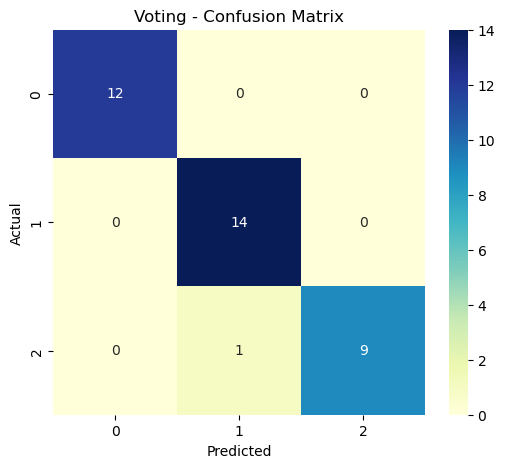

In [16]:
# ---------------------------------------------------------
# 12. Soft Voting
#    - 여러 모델의 예측 확률을 평균내는 방식
# ---------------------------------------------------------
voting_model = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=2000, random_state=42)),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=42)),
        ("svc", SVC(probability=True, random_state=42))
    ],
    voting="soft"
)

result_voting = evaluate_model(
    voting_model, X_train, y_train, X_test, y_test,
    model_name="Voting - Soft Voting"
)

cm_vote = confusion_matrix(y_test, result_voting["y_pred"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_vote, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Voting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


=== Stacking 결과 ===
Accuracy: 0.9722
Macro F1: 0.971

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



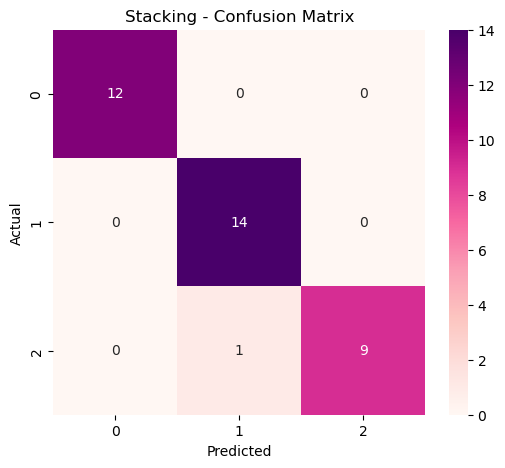

In [17]:
# ---------------------------------------------------------
# 13. Stacking
#    - 여러 모델 결과를 다시 하나의 모델이 학습
# ---------------------------------------------------------
stacking_model = StackingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=2000, random_state=42)),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=42)),
        ("knn", KNeighborsClassifier())
    ],
    final_estimator=LogisticRegression(max_iter=2000, random_state=42)
)

result_stacking = evaluate_model(
    stacking_model, X_train, y_train, X_test, y_test,
    model_name="Stacking"
)

cm_stack = confusion_matrix(y_test, result_stacking["y_pred"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_stack, annot=True, fmt="d", cmap="RdPu")
plt.title("Stacking - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
# ---------------------------------------------------------
# 14. 모델 비교표
# ---------------------------------------------------------
result_table = pd.DataFrame([
    {
        "model": result_lr["model_name"],
        "accuracy": result_lr["accuracy"],
        "macro_f1": result_lr["macro_f1"]
    },
    {
        "model": result_bagging["model_name"],
        "accuracy": result_bagging["accuracy"],
        "macro_f1": result_bagging["macro_f1"]
    },
    {
        "model": result_adaboost["model_name"],
        "accuracy": result_adaboost["accuracy"],
        "macro_f1": result_adaboost["macro_f1"]
    },
    {
        "model": result_gb["model_name"],
        "accuracy": result_gb["accuracy"],
        "macro_f1": result_gb["macro_f1"]
    },
    {
        "model": result_rf["model_name"],
        "accuracy": result_rf["accuracy"],
        "macro_f1": result_rf["macro_f1"]
    },
    {
        "model": result_extra["model_name"],
        "accuracy": result_extra["accuracy"],
        "macro_f1": result_extra["macro_f1"]
    },
    {
        "model": result_voting["model_name"],
        "accuracy": result_voting["accuracy"],
        "macro_f1": result_voting["macro_f1"]
    },
    {
        "model": result_stacking["model_name"],
        "accuracy": result_stacking["accuracy"],
        "macro_f1": result_stacking["macro_f1"]
    }
]).sort_values("macro_f1", ascending=False)

print("=== 전체 모델 비교표 ===")
display(result_table)

=== 전체 모델 비교표 ===


,model,accuracy,macro_f1
1,Bagging - DecisionTree base,1.000000,1.000000
4,Ensemble - Random Forest,1.000000,1.000000
5,Ensemble - Extra Trees,1.000000,1.000000
6,Voting - Soft Voting,0.972222,0.970962
7,Stacking,0.972222,0.970962
3,Boosting - GradientBoosting,0.944444,0.945313
0,Baseline - Logistic Regression,0.944444,0.940741
2,Boosting - AdaBoost,0.916667,0.919778


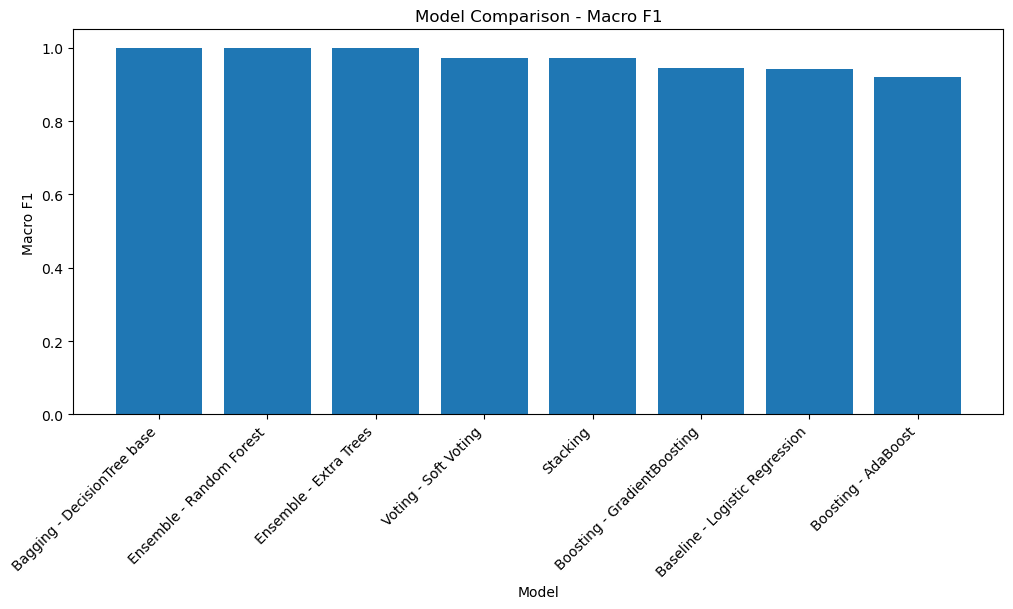

In [19]:
# ---------------------------------------------------------
# 15. 비교표 시각화
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.bar(result_table["model"], result_table["macro_f1"])
plt.title("Model Comparison - Macro F1")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=45, ha="right")
plt.show()

=== Random Forest 중요 변수 ===


,feature,importance
9,color_intensity,0.180805
6,flavanoids,0.172865
12,proline,0.151067
0,alcohol,0.112384
10,hue,0.099592
11,od280/od315_of_diluted_wines,0.090361
5,total_phenols,0.051563
1,malic_acid,0.033140
4,magnesium,0.032820
3,alcalinity_of_ash,0.026338


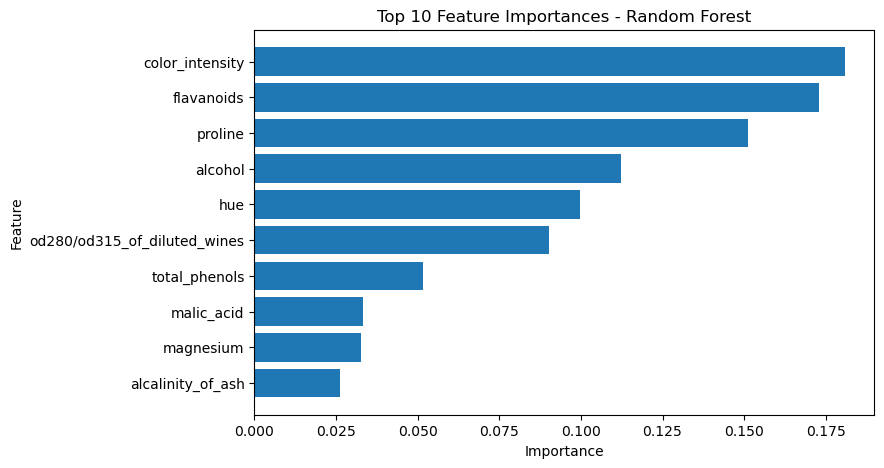

In [20]:
# ---------------------------------------------------------
# 16. 중요 변수 해석
#    - 트리 계열 모델은 feature importance 제공
# ---------------------------------------------------------
rf_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": result_rf["model"].feature_importances_
}).sort_values("importance", ascending=False)

print("=== Random Forest 중요 변수 ===")
display(rf_importance_df)

plt.figure(figsize=(8, 5))
plt.barh(rf_importance_df["feature"].head(10), rf_importance_df["importance"].head(10))
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [21]:
extra_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": result_extra["model"].feature_importances_
}).sort_values("importance", ascending=False)

print("=== Extra Trees 중요 변수 ===")
display(extra_importance_df)

=== Extra Trees 중요 변수 ===


,feature,importance
6,flavanoids,0.153810
12,proline,0.142783
9,color_intensity,0.122128
0,alcohol,0.115346
11,od280/od315_of_diluted_wines,0.108025
10,hue,0.084683
5,total_phenols,0.063569
1,malic_acid,0.052624
4,magnesium,0.039767
3,alcalinity_of_ash,0.033938


In [22]:
# ---------------------------------------------------------
# 17. 간단 AutoML
#    - 외부 라이브러리 없이 "자동 비교" 개념 구현
#    - 여러 모델을 자동으로 돌리고 성능표 만들기
# ---------------------------------------------------------
candidate_models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(probability=True, random_state=42)
}

automl_results = []

for model_name, model in candidate_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    automl_results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro")
    })

automl_df = pd.DataFrame(automl_results).sort_values("macro_f1", ascending=False)

print("=== 간단 AutoML 결과표 ===")
display(automl_df)

=== 간단 AutoML 결과표 ===


,model,accuracy,macro_f1
2,RandomForest,1.000000,1.000000
3,ExtraTrees,1.000000,1.000000
1,DecisionTree,0.944444,0.945741
4,GradientBoosting,0.944444,0.945313
0,LogisticRegression,0.944444,0.940741
5,AdaBoost,0.916667,0.919778
6,KNN,0.805556,0.802469
7,SVC,0.694444,0.557808


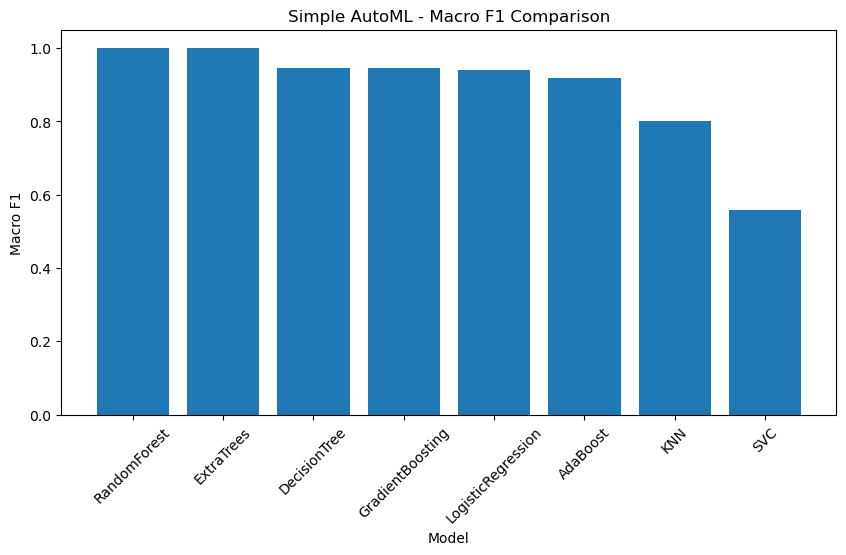

In [23]:
plt.figure(figsize=(10, 5))
plt.bar(automl_df["model"], automl_df["macro_f1"])
plt.title("Simple AutoML - Macro F1 Comparison")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=45)
plt.show()

In [24]:
best_automl_model_name = automl_df.iloc[0]["model"]
print("=== AutoML 최고 모델 ===")
print("Best Model:", best_automl_model_name)

=== AutoML 최고 모델 ===
Best Model: RandomForest



=== AutoML 최고 모델 상세 결과 ===
Accuracy: 1.0
Macro F1: 1.0

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



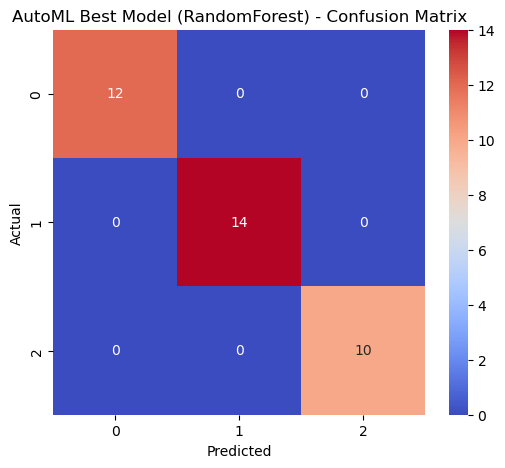

In [25]:
# ---------------------------------------------------------
# 18. AutoML 최고 모델 재확인
# ---------------------------------------------------------
best_automl_model = candidate_models[best_automl_model_name]
best_automl_model.fit(X_train, y_train)
best_automl_pred = best_automl_model.predict(X_test)

print("\n=== AutoML 최고 모델 상세 결과 ===")
print("Accuracy:", round(accuracy_score(y_test, best_automl_pred), 4))
print("Macro F1:", round(f1_score(y_test, best_automl_pred, average="macro"), 4))
print("\n[Classification Report]")
print(classification_report(y_test, best_automl_pred))

cm_automl = confusion_matrix(y_test, best_automl_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_automl, annot=True, fmt="d", cmap="coolwarm")
plt.title(f"AutoML Best Model ({best_automl_model_name}) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
# ---------------------------------------------------------
# 19. GridSearchCV 예시
#    - AutoML과 별도로 튜닝 개념도 함께 보여주기
# ---------------------------------------------------------
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("=== GridSearchCV 결과 ===")
print("Best Params:", grid.best_params_)
print("Best CV Score:", round(grid.best_score_, 4))

=== GridSearchCV 결과 ===
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.9792


In [27]:
best_tuned_rf = grid.best_estimator_
best_tuned_pred = best_tuned_rf.predict(X_test)

print("=== Tuned Random Forest 결과 ===")
print("Accuracy:", round(accuracy_score(y_test, best_tuned_pred), 4))
print("Macro F1:", round(f1_score(y_test, best_tuned_pred, average="macro"), 4))
print("\n[Classification Report]")
print(classification_report(y_test, best_tuned_pred))

=== Tuned Random Forest 결과 ===
Accuracy: 1.0
Macro F1: 1.0

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [28]:
# ---------------------------------------------------------
# 20. AutoML / 튜닝 / 앙상블 비교표
# ---------------------------------------------------------
summary_compare = pd.DataFrame([
    {
        "group": "Baseline",
        "model": result_lr["model_name"],
        "accuracy": result_lr["accuracy"],
        "macro_f1": result_lr["macro_f1"]
    },
    {
        "group": "Ensemble",
        "model": result_rf["model_name"],
        "accuracy": result_rf["accuracy"],
        "macro_f1": result_rf["macro_f1"]
    },
    {
        "group": "Ensemble",
        "model": result_voting["model_name"],
        "accuracy": result_voting["accuracy"],
        "macro_f1": result_voting["macro_f1"]
    },
    {
        "group": "Ensemble",
        "model": result_stacking["model_name"],
        "accuracy": result_stacking["accuracy"],
        "macro_f1": result_stacking["macro_f1"]
    },
    {
        "group": "AutoML",
        "model": f"AutoML Best ({best_automl_model_name})",
        "accuracy": accuracy_score(y_test, best_automl_pred),
        "macro_f1": f1_score(y_test, best_automl_pred, average="macro")
    },
    {
        "group": "Tuning",
        "model": "Tuned Random Forest",
        "accuracy": accuracy_score(y_test, best_tuned_pred),
        "macro_f1": f1_score(y_test, best_tuned_pred, average="macro")
    }
]).sort_values("macro_f1", ascending=False)

print("=== 최종 요약 비교표 ===")
display(summary_compare)

=== 최종 요약 비교표 ===


,group,model,accuracy,macro_f1
1,Ensemble,Ensemble - Random Forest,1.000000,1.000000
4,AutoML,AutoML Best (RandomForest),1.000000,1.000000
5,Tuning,Tuned Random Forest,1.000000,1.000000
2,Ensemble,Voting - Soft Voting,0.972222,0.970962
3,Ensemble,Stacking,0.972222,0.970962
0,Baseline,Baseline - Logistic Regression,0.944444,0.940741


In [29]:
# ---------------------------------------------------------
# 21. 발표용 해석 문장 자동 출력
# ---------------------------------------------------------
best_row = summary_compare.iloc[0]

print("=== 발표용 요약 문장 ===")
print(f"이번 실습에서 가장 좋은 모델은 '{best_row['model']}' 입니다.")
print(f"Accuracy는 {best_row['accuracy']:.4f}, Macro F1은 {best_row['macro_f1']:.4f} 입니다.")
print("단, 성능만이 아니라 해석 가능성, 구현 난이도, 운영 편의성도 함께 고려해야 합니다.")

=== 발표용 요약 문장 ===
이번 실습에서 가장 좋은 모델은 'Ensemble - Random Forest' 입니다.
Accuracy는 1.0000, Macro F1은 1.0000 입니다.
단, 성능만이 아니라 해석 가능성, 구현 난이도, 운영 편의성도 함께 고려해야 합니다.


In [30]:
# ---------------------------------------------------------
# 22. 발표용 표 1 - 모델별 성능
# ---------------------------------------------------------
presentation_table_1 = summary_compare.copy()
presentation_table_1["accuracy"] = presentation_table_1["accuracy"].round(4)
presentation_table_1["macro_f1"] = presentation_table_1["macro_f1"].round(4)

print("=== 발표용 표 1: 모델별 성능 ===")
display(presentation_table_1)

=== 발표용 표 1: 모델별 성능 ===


,group,model,accuracy,macro_f1
1,Ensemble,Ensemble - Random Forest,1.0000,1.0000
4,AutoML,AutoML Best (RandomForest),1.0000,1.0000
5,Tuning,Tuned Random Forest,1.0000,1.0000
2,Ensemble,Voting - Soft Voting,0.9722,0.9710
3,Ensemble,Stacking,0.9722,0.9710
0,Baseline,Baseline - Logistic Regression,0.9444,0.9407


In [31]:
# ---------------------------------------------------------
# 23. 발표용 표 2 - 중요 변수
# ---------------------------------------------------------
presentation_table_2 = rf_importance_df.head(10).copy()
presentation_table_2["importance"] = presentation_table_2["importance"].round(4)

print("=== 발표용 표 2: 중요 변수 Top 10 ===")
display(presentation_table_2)

=== 발표용 표 2: 중요 변수 Top 10 ===


,feature,importance
9,color_intensity,0.1808
6,flavanoids,0.1729
12,proline,0.1511
0,alcohol,0.1124
10,hue,0.0996
11,od280/od315_of_diluted_wines,0.0904
5,total_phenols,0.0516
1,malic_acid,0.0331
4,magnesium,0.0328
3,alcalinity_of_ash,0.0263


In [32]:
# ---------------------------------------------------------
# 24. 팀 발표용 질문
# ---------------------------------------------------------
print("\n=== 팀 발표용 질문 ===")
print("1. baseline 모델 대비 어떤 모델이 가장 개선 폭이 컸는가?")
print("2. Bagging, Boosting, Voting, Stacking 중 어떤 방식이 가장 효과적이었는가?")
print("3. AutoML 최고 모델과 수작업 앙상블 모델은 어떻게 달랐는가?")
print("4. 중요 변수는 무엇이며, 이전 주차 분석 결과와 연결되는가?")
print("5. 실제 업무에 도입한다면 어떤 모델을 추천할 것인가?")
print("6. 그 이유는 성능 때문인가, 해석 때문인가, 운영 때문인가?")


=== 팀 발표용 질문 ===
1. baseline 모델 대비 어떤 모델이 가장 개선 폭이 컸는가?
2. Bagging, Boosting, Voting, Stacking 중 어떤 방식이 가장 효과적이었는가?
3. AutoML 최고 모델과 수작업 앙상블 모델은 어떻게 달랐는가?
4. 중요 변수는 무엇이며, 이전 주차 분석 결과와 연결되는가?
5. 실제 업무에 도입한다면 어떤 모델을 추천할 것인가?
6. 그 이유는 성능 때문인가, 해석 때문인가, 운영 때문인가?


In [33]:
# ---------------------------------------------------------
# 25. 최종 정리
# ---------------------------------------------------------
print("\n=== 오늘 실습 정리 ===")
print("1. 기준 모델을 만들었다.")
print("2. Bagging, Boosting, Voting, Stacking을 적용했다.")
print("3. 여러 모델을 자동 비교하는 간단 AutoML을 구현했다.")
print("4. GridSearchCV로 튜닝도 수행했다.")
print("5. 성능, 중요 변수, 발표용 표까지 정리했다.")


=== 오늘 실습 정리 ===
1. 기준 모델을 만들었다.
2. Bagging, Boosting, Voting, Stacking을 적용했다.
3. 여러 모델을 자동 비교하는 간단 AutoML을 구현했다.
4. GridSearchCV로 튜닝도 수행했다.
5. 성능, 중요 변수, 발표용 표까지 정리했다.


In [34]:
# end